In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

# Optional: SHAP
!pip install shap
import shap

In [22]:
!pip3 install joblib
import os
import joblib

# Ensure folder exists
os.makedirs("models", exist_ok=True)

In [24]:
# 4.0 Setup (use preprocessed data from Step 3)
# Assume X_scaled, y, X_selected from Step 3
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, silhouette_score
#from sklearn.externals import joblib  # or import joblib
#import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [25]:
# 4.1a Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ),
    "SVM_RBF": SVC(kernel='rbf', probability=True, random_state=42)
}

supervised_results_nottuned = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:,1]

    supervised_results_nottuned[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "f1": f1_score(y_test, y_pred)
    }

    # Save model artefact
    joblib.dump(clf, f"models/{name}.joblib")

supervised_results_nottuned


{'LogReg': {'accuracy': 0.8688524590163934,
  'roc_auc': np.float64(0.9567099567099567),
  'f1': 0.8620689655172413},
 'DecisionTree': {'accuracy': 0.7213114754098361,
  'roc_auc': np.float64(0.7234848484848485),
  'f1': 0.711864406779661},
 'RandomForest': {'accuracy': 0.9180327868852459,
  'roc_auc': np.float64(0.9577922077922079),
  'f1': 0.9152542372881356},
 'XGBoost': {'accuracy': 0.9016393442622951,
  'roc_auc': np.float64(0.9458874458874458),
  'f1': 0.9},
 'SVM_RBF': {'accuracy': 0.6885245901639344,
  'roc_auc': np.float64(0.8333333333333334),
  'f1': 0.5777777777777777}}

In [26]:
#Tuning Only the Best Models
# 4.1a Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


#Logistic Regression Tuning
#Parameters to tune
lr_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("Best LR Params:")
print(grid_lr.best_params_)



#Random Forest Tuning
#Parameters to tune
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:")
print(rf_grid.best_params_)
#'



#XGBoost Tuning
#Parameters
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print(xgb_grid.best_params_)


#SVM Tuning
#SVM performance is highly dependent on tuning.
#Parameters
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}
#``
svm_grid = GridSearchCV(
    SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

print(svm_grid.best_params_)


#Replace the Models Dictionary
models = {
    "LogReg": best_lr,
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": best_rf,
    "XGBoost": best_xgb,
    "SVM_RBF": best_svm
}

supervised_results = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:,1]

    supervised_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "f1": f1_score(y_test, y_pred)
    }

    # Save model artefact
    joblib.dump(clf, f"models/{name}.joblib")

supervised_results


Best LR Params:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best RF Params:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
{'C': 10, 'gamma': 'scale'}


{'LogReg': {'accuracy': 0.8524590163934426,
  'roc_auc': np.float64(0.9577922077922079),
  'f1': 0.847457627118644},
 'DecisionTree': {'accuracy': 0.7213114754098361,
  'roc_auc': np.float64(0.7234848484848485),
  'f1': 0.711864406779661},
 'RandomForest': {'accuracy': 0.9344262295081968,
  'roc_auc': np.float64(0.9632034632034633),
  'f1': 0.9310344827586207},
 'XGBoost': {'accuracy': 0.9016393442622951,
  'roc_auc': np.float64(0.946969696969697),
  'f1': 0.896551724137931},
 'SVM_RBF': {'accuracy': 0.8852459016393442,
  'roc_auc': np.float64(0.9512987012987013),
  'f1': 0.8727272727272727}}

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [27]:
# 4.1b Unsupervised models (K-Means, DBSCAN, Hierarchical)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

X_cluster = X_selected  # use selected features from Step 3

# K-Means (try k=2..6, pick best silhouette)
k_range = range(2, 7)
kmeans_scores = {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    kmeans_scores[k] = score
best_k = max(kmeans_scores, key=kmeans_scores.get)

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_cluster)
kmeans_sil = silhouette_score(X_cluster, kmeans_labels)
joblib.dump(kmeans, "models/KMeans_best.joblib")

# DBSCAN #--- no tuning ---
#dbscan = DBSCAN(eps=0.8, min_samples=5)
#db_labels = dbscan.fit_predict(X_cluster)
## Filter noise (-1) for silhouette
#mask = db_labels != -1
#db_sil = silhouette_score(X_cluster[mask], db_labels[mask]) if len(set(db_labels)) > 1 else None
#joblib.dump(dbscan, "models/DBSCAN.joblib")

# ------------------------------------------------------------
# DBSCAN Hyperparameter Search
# ------------------------------------------------------------

eps_values = [0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 10]

best_dbscan = None
best_db_labels = None
best_db_sil = -1
best_params = None

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_cluster)

        # Remove noise points
        mask = labels != -1

        # Must have at least 2 clusters
        n_clusters = len(
            set(labels[mask])
        )

        if n_clusters > 1 and np.sum(mask) > 1:

            sil = silhouette_score(
                X_cluster[mask],
                labels[mask]
            )

            if sil > best_db_sil:

                best_db_sil = sil
                best_dbscan = dbscan
                best_db_labels = labels
                best_params = {
                    "eps": eps,
                    "min_samples": min_samples
                }

# Save best model
joblib.dump(
    best_dbscan,
    "models/DBSCAN_best.joblib"
)

print("Best DBSCAN Parameters:")
print(best_params)

print("Best DBSCAN Silhouette:")
print(best_db_sil)

#end for # DBSCAN Hyperparameter Search


# Hierarchical (Agglomerative)
hier = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hier.fit_predict(X_cluster)
hier_sil = silhouette_score(X_cluster, hier_labels)
joblib.dump(hier, "models/Hierarchical.joblib")


#not updated results dictionary
#unsupervised_results = {
#    "KMeans": {"k": best_k, "silhouette": kmeans_sil},
#    "DBSCAN": {"silhouette": db_sil},
#    "Hierarchical": {"k": best_k, "silhouette": hier_sil}
#}

if best_params is None:

    best_params = {
        "eps": None,
        "min_samples": None
    }

    best_db_sil = None
    
# tuned
unsupervised_results = {
    "KMeans": {
        "k": best_k,
        "silhouette": kmeans_sil
    },

    "DBSCAN": {
        "eps": best_params["eps"],
        "min_samples": best_params["min_samples"],
        "silhouette": best_db_sil
    },

    "Hierarchical": {
        "k": best_k,
        "silhouette": hier_sil
    }
}
unsupervised_results

C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

Best DBSCAN Parameters:
None
Best DBSCAN Silhouette:
-1


{'KMeans': {'k': 2, 'silhouette': np.float64(0.5461810453681777)},
 'DBSCAN': {'eps': None, 'min_samples': None, 'silhouette': None},
 'Hierarchical': {'k': 2, 'silhouette': np.float64(0.5397890229980801)}}

In [28]:
for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_cluster)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        print(
            f"eps={eps}, "
            f"min_samples={min_samples}, "
            f"clusters={n_clusters}, "
            f"noise={n_noise}"
        )

eps=0.3, min_samples=3, clusters=0, noise=303
eps=0.3, min_samples=5, clusters=0, noise=303
eps=0.3, min_samples=10, clusters=0, noise=303
eps=0.5, min_samples=3, clusters=0, noise=303
eps=0.5, min_samples=5, clusters=0, noise=303
eps=0.5, min_samples=10, clusters=0, noise=303
eps=0.8, min_samples=3, clusters=0, noise=303
eps=0.8, min_samples=5, clusters=0, noise=303
eps=0.8, min_samples=10, clusters=0, noise=303
eps=1.0, min_samples=3, clusters=1, noise=300
eps=1.0, min_samples=5, clusters=0, noise=303
eps=1.0, min_samples=10, clusters=0, noise=303


C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Henry\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

Best K: 2
Best DBSCAN: eps=None, min_samples=None, silhouette=-1.000


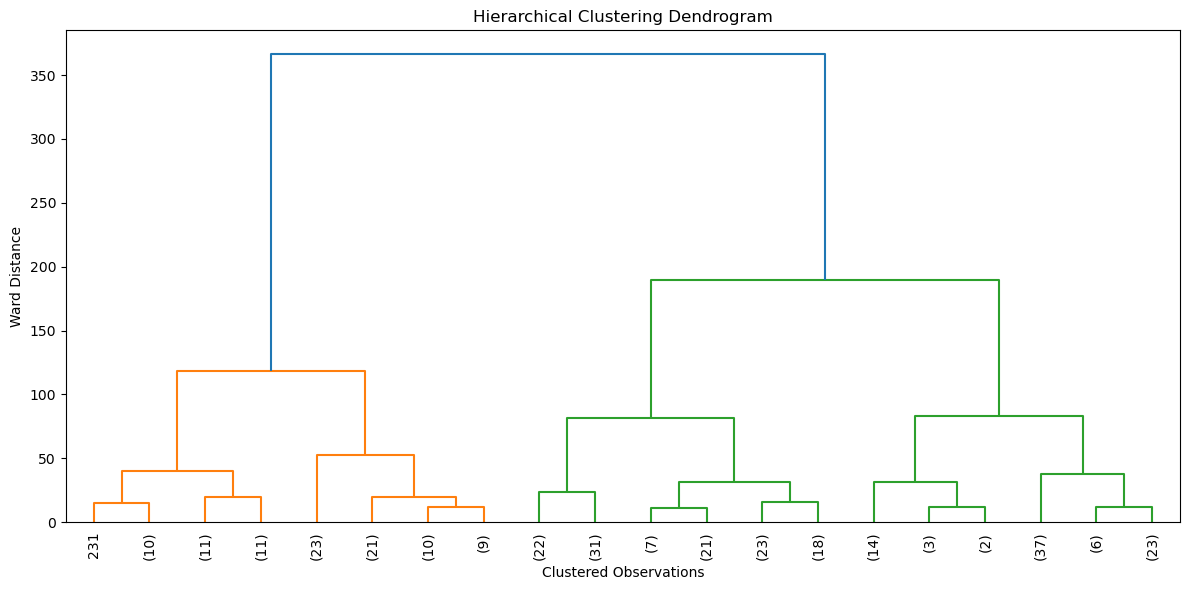

{'KMeans': {'k': 2, 'silhouette': np.float64(0.5461810453681777)}, 'DBSCAN': {'eps': None, 'min_samples': None, 'silhouette': -1}, 'Hierarchical': {'k': 2, 'silhouette': np.float64(0.5397890229980801)}}


In [29]:
# ============================================================
# STEP 4.1b - UNSUPERVISED MODELS
# K-Means, DBSCAN, Hierarchical Clustering
# with the DENDROGRAMs
# ============================================================

import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

# ------------------------------------------------------------
# Clustering Dataset
# ------------------------------------------------------------

X_cluster = X_selected

# ------------------------------------------------------------
# K-MEANS
# ------------------------------------------------------------

k_range = range(2, 7)

kmeans_scores = {}

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(X_cluster)

    score = silhouette_score(
        X_cluster,
        labels
    )

    kmeans_scores[k] = score

best_k = max(
    kmeans_scores,
    key=kmeans_scores.get
)

print("Best K:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_cluster)

kmeans_sil = silhouette_score(
    X_cluster,
    kmeans_labels
)

joblib.dump(
    kmeans,
    "models/KMeans_best.joblib"
)

# ------------------------------------------------------------
# DBSCAN (no tuning)
# ------------------------------------------------------------
#
#dbscan = DBSCAN(
#    eps=0.8,
#    min_samples=5
#)
#
#db_labels = dbscan.fit_predict(X_cluster)
#
#mask = db_labels != -1
#
#if len(set(db_labels)) > 1 and np.sum(mask) > 1:
#
#    db_sil = silhouette_score(
#        X_cluster[mask],
#        db_labels[mask]
#    )
#
#else:
#
#    db_sil = None
#
#joblib.dump(
#    dbscan,
#    "models/DBSCAN.joblib"
#)
#end of DBSCAN (no tuning)

# ------------------------------------------------------------
# DBSCAN (Hyperparameter Tuning)
# ------------------------------------------------------------

eps_values = [0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 10]

best_dbscan = None
best_db_labels = None
best_db_sil = -1
best_eps = None
best_min_samples = None

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_cluster)

        # Remove noise points
        mask = labels != -1

        # Need at least 2 valid clusters
        if np.sum(mask) > 1:

            valid_labels = labels[mask]

            if len(set(valid_labels)) > 1:

                sil = silhouette_score(
                    X_cluster[mask],
                    valid_labels
                )

                if sil > best_db_sil:

                    best_db_sil = sil
                    best_dbscan = dbscan
                    best_db_labels = labels
                    best_eps = eps
                    best_min_samples = min_samples

print(
    f"Best DBSCAN: eps={best_eps}, "
    f"min_samples={best_min_samples}, "
    f"silhouette={best_db_sil:.3f}"
)

joblib.dump(
    best_dbscan,
    "models/DBSCAN_best.joblib"
)


# ------------------------------------------------------------
# HIERARCHICAL CLUSTERING
# ------------------------------------------------------------

hier = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

hier_labels = hier.fit_predict(X_cluster)

hier_sil = silhouette_score(
    X_cluster,
    hier_labels
)

joblib.dump(
    hier,
    "models/Hierarchical.joblib"
)

# ------------------------------------------------------------
# HIERARCHICAL DENDROGRAM
# ------------------------------------------------------------

linked = linkage(
    X_cluster,
    method='ward'
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Clustered Observations"
)

plt.ylabel(
    "Ward Distance"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# RESULTS SUMMARY
# ------------------------------------------------------------

# DBSCAN with no tuning
#unsupervised_results = {
#    "KMeans": {
#        "k": best_k,
#        "silhouette": kmeans_sil
#    },
#    "DBSCAN": {
#        "silhouette": db_sil
#    },
#    "Hierarchical": {
#        "k": best_k,
#        "silhouette": hier_sil
#    }
#}

if best_params is None:

    best_params = {
        "eps": None,
        "min_samples": None
    }

    best_db_sil = None
    
# includes DBSCAN with tuning
unsupervised_results = {
    "KMeans": {
        "k": best_k,
        "silhouette": kmeans_sil
    },

    "DBSCAN": {
        "eps": best_params["eps"],
        "min_samples": best_params["min_samples"],
        "silhouette": best_db_sil
    },

    "Hierarchical": {
        "k": best_k,
        "silhouette": hier_sil
    }
}
print(unsupervised_results)


In [30]:
# 4.2 Evaluation & comparison
import pandas as pd

# Supervised comparison table
sup_df = pd.DataFrame(supervised_results).T
print("Supervised Models Performance:\n", sup_df)

# Unsupervised comparison table
unsup_df = pd.DataFrame(unsupervised_results).T
print("\nUnsupervised Models Performance:\n", unsup_df)


Supervised Models Performance:
               accuracy   roc_auc        f1
LogReg        0.852459  0.957792  0.847458
DecisionTree  0.721311  0.723485  0.711864
RandomForest  0.934426  0.963203  0.931034
XGBoost       0.901639  0.946970  0.896552
SVM_RBF       0.885246  0.951299  0.872727

Unsupervised Models Performance:
                 k  silhouette  eps  min_samples
KMeans        2.0    0.546181  NaN          NaN
DBSCAN        NaN   -1.000000  NaN          NaN
Hierarchical  2.0    0.539789  NaN          NaN


In [32]:
# 4.3 Reproducibility: configs + artefacts
import json
import os

os.makedirs("configs", exist_ok=True)
os.makedirs("models", exist_ok=True)

config = {
    "random_state": 42,
    "train_test_split": {"test_size": 0.2, "stratify": True},
    "models": {
        "LogReg": {"max_iter": 1000},
        "DecisionTree": {"random_state": 42},
        "RandomForest": {"n_estimators": 200, "random_state": 42},
        "XGBoost": {
            "n_estimators": 300, "max_depth": 4,
            "learning_rate": 0.05, "subsample": 0.8,
            "colsample_bytree": 0.8, "random_state": 42
        },
        "SVM_RBF": {"kernel": "rbf", "probability": True, "random_state": 42},
        "KMeans": {"best_k": int(best_k)},
        "DBSCAN": {"eps": 0.8, "min_samples": 5},
        "Hierarchical": {"n_clusters": int(best_k), "linkage": "ward"}
    }
}

with open("configs/experiment_heart.json", "w") as f:
    json.dump(config, f, indent=4)
